# CIC-IDS-2018 데이터 전처리

**데이터셋**: UNB CIC-IDS-2018  
**목표**: 딥러닝 기반 IPS 모델 학습을 위한 전처리 파이프라인 구성

---
### 전처리 순서
1. 라이브러리 임포트  
2. 데이터 로드 & 병합  
3. EDA (분포 확인, 결측치 현황)  
4. 결측치 / 이상값 처리  
5. 레이블 정규화 및 인코딩  
6. 피처 스케일링  
7. 클래스 불균형 처리  
8. 전처리 결과 저장

## 1. 라이브러리 임포트

In [3]:
import os
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 경로 설정
BASE_DIR   = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR   = os.path.join(BASE_DIR, "dataset")
OUTPUT_DIR = os.path.join(BASE_DIR, "processed")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("라이브러리 로드 완료")
print(f"데이터 경로: {DATA_DIR}")
print(f"출력 경로:   {OUTPUT_DIR}")

라이브러리 로드 완료
데이터 경로: c:\Users\SSAFY\Desktop\Claude Code\프로젝트\DeepFence\dataset
출력 경로:   c:\Users\SSAFY\Desktop\Claude Code\프로젝트\DeepFence\processed


## 2. 데이터 로드 & 병합

In [4]:
csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".csv")])
print(f"발견된 CSV 파일 수: {len(csv_files)}")
for f in csv_files:
    print(f"  - {f}")

발견된 CSV 파일 수: 10
  - Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
  - Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
  - Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
  - Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
  - Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
  - Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
  - Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv
  - Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv
  - Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv
  - Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv


In [5]:
dfs = []
for fname in tqdm(csv_files, desc="CSV 로드"):
    fpath = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(fpath, encoding="utf-8", low_memory=False)
    df["source_file"] = fname
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
print(f"\n총 샘플 수: {len(raw):,}")
print(f"컬럼 수:    {raw.shape[1]}")
raw.head(3)

CSV 로드: 100%|██████████| 10/10 [02:21<00:00, 14.14s/it]



총 샘플 수: 16,233,002
컬럼 수:    85


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file,Flow ID,Src IP,Src Port,Dst IP
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773.0,202,0,...,0.0,0.0,0.0,0.0,Benign,Friday-02-03-2018_TrafficForML_CICFlowMeter.csv,NaN,NaN,NaN,NaN
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0.0,38,0,...,0.0,0.0,0.0,0.0,Benign,Friday-02-03-2018_TrafficForML_CICFlowMeter.csv,NaN,NaN,NaN,NaN
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527.0,385,0,...,0.0,0.0,0.0,0.0,Benign,Friday-02-03-2018_TrafficForML_CICFlowMeter.csv,NaN,NaN,NaN,NaN


## 3. EDA

=== 원본 레이블 분포 ===
Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87


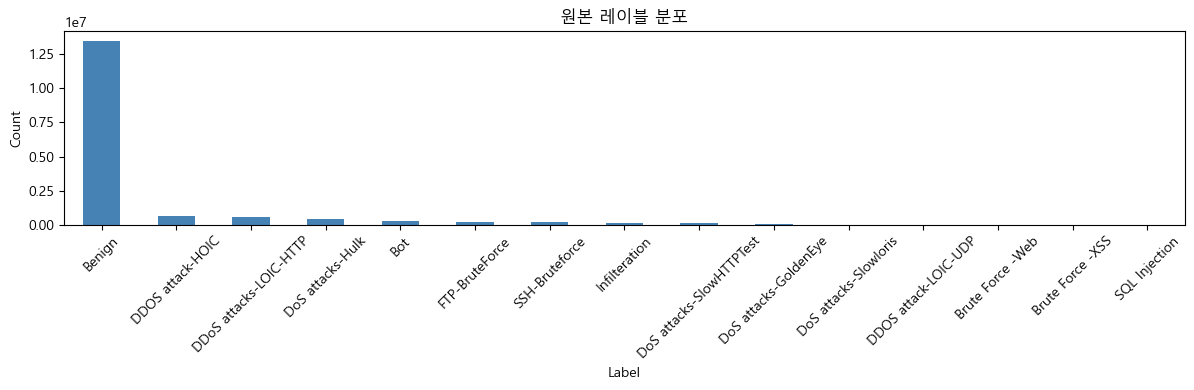

In [6]:
# 컬럼명 공백 제거
raw.columns = raw.columns.str.strip()

# 헤더가 데이터로 섞인 행 제거
raw = raw[raw["Label"] != "Label"].reset_index(drop=True)

# 레이블 분포
label_counts = raw["Label"].astype(str).str.strip().value_counts()
print("=== 원본 레이블 분포 ===")
print(label_counts.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
label_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("원본 레이블 분포")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# 결측치 및 무한대 현황
feature_cols = [c for c in raw.columns if c not in ("Label", "Timestamp", "source_file")]
raw[feature_cols] = raw[feature_cols].apply(pd.to_numeric, errors="coerce")
raw.replace([np.inf, -np.inf], np.nan, inplace=True)

nan_per_col = raw[feature_cols].isna().sum()
nan_cols = nan_per_col[nan_per_col > 0].sort_values(ascending=False)

print(f"결측치가 있는 컬럼 수: {len(nan_cols)}")
print(nan_cols.to_string() if len(nan_cols) else "없음")

결측치가 있는 컬럼 수: 6
Src IP         16232943
Flow ID        16232943
Dst IP         16232943
Src Port        8284195
Flow Pkts/s       95760
Flow Byts/s       95760


## 4. 결측치 / 이상값 처리

In [8]:
# 불필요한 컬럼 제거
# - Timestamp, source_file
# - Flow ID, Src IP, Src Port, Dst IP
drop_cols = ["Timestamp", "source_file", "Flow ID", "Src IP", "Src Port", "Dst IP"]
raw.drop(columns=[c for c in drop_cols if c in raw.columns], inplace=True)

# NaN 비율 50% 초과 컬럼 제거
thresh = int(len(raw) * 0.5)
before = raw.shape[1]
raw.dropna(axis=1, thresh=thresh, inplace=True)
feature_cols = [c for c in raw.columns if c != "Label"]
print(f"컬럼 제거 (NaN>50%): {before - raw.shape[1]}개 → 남은 피처: {len(feature_cols)}개")

# 나머지 결측치 → 중앙값 대체
for col in tqdm(feature_cols, desc="중앙값 대체"):
    if raw[col].isna().any():
        raw[col] = raw[col].fillna(raw[col].median())

print(f"처리 후 NaN 수: {raw[feature_cols].isna().sum().sum()}")

컬럼 제거 (NaN>50%): 0개 → 남은 피처: 78개


중앙값 대체: 100%|██████████| 78/78 [00:01<00:00, 56.94it/s]


처리 후 NaN 수: 0


In [9]:
# 분산 = 0 인 피처 제거 (모든 값이 동일 → 정보 없음)
zero_var = [c for c in feature_cols if raw[c].std() == 0]
if zero_var:
    print(f"분산=0 피처 제거: {zero_var}")
    raw.drop(columns=zero_var, inplace=True)
    feature_cols = [c for c in raw.columns if c != "Label"]
else:
    print("분산=0 피처 없음")

print(f"최종 피처 수: {len(feature_cols)}")

분산=0 피처 제거: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
최종 피처 수: 70


## 5. 레이블 정규화 및 인코딩

In [10]:
# 세부 공격명 → 상위 카테고리로 통합
label_map = {
    "Benign":                     "Benign",
    "Bot":                        "Bot",
    "FTP-BruteForce":             "Brute Force",
    "SSH-Bruteforce":             "Brute Force",
    "Brute Force -Web":           "Brute Force",
    "Brute Force -XSS":           "Brute Force",
    "SQL Injection":              "SQL Injection",
    "DoS attacks-Hulk":           "DoS",
    "DoS attacks-GoldenEye":      "DoS",
    "DoS attacks-Slowloris":      "DoS",
    "DoS attacks-SlowHTTPTest":   "DoS",
    "DDoS attacks-LOIC-HTTP":     "DDoS",
    "DDOS attack-LOIC-UDP":       "DDoS",
    "DDOS attack-HOIC":           "DDoS",
    "Infilteration":              "Infiltration",
}

raw["Label"] = raw["Label"].astype(str).str.strip().map(label_map)

# 매핑 실패 행 제거
unmapped = raw["Label"].isna().sum()
if unmapped > 0:
    print(f"매핑 실패 행 제거: {unmapped:,}개")
    raw.dropna(subset=["Label"], inplace=True)

print("=== 통합 레이블 분포 ===")
print(raw["Label"].value_counts().to_string())

=== 통합 레이블 분포 ===
Label
Benign           13484708
DDoS              1263933
DoS                654300
Brute Force        381790
Bot                286191
Infiltration       161934
SQL Injection          87


In [11]:
# LabelEncoder 적용
le = LabelEncoder()
raw["Label_enc"] = le.fit_transform(raw["Label"])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_).tolist()))
print("레이블 인코딩 매핑:")
for k, v in label_mapping.items():
    print(f"  {v}: {k}")

레이블 인코딩 매핑:
  0: Benign
  1: Bot
  2: Brute Force
  3: DDoS
  4: DoS
  5: Infiltration
  6: SQL Injection


## 6. 피처 스케일링

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(raw[feature_cols].values)

print(f"스케일링 완료")
print(f"  shape : {X_scaled.shape}")
print(f"  mean  : {X_scaled.mean():.6f}  (≈ 0 이면 정상)")
print(f"  std   : {X_scaled.std():.6f}   (≈ 1 이면 정상)")

스케일링 완료
  shape : (16232943, 70)
  mean  : -0.000000  (≈ 0 이면 정상)
  std   : 1.000000   (≈ 1 이면 정상)


## 7. 클래스 불균형 처리

Benign 샘플이 압도적으로 많아 언더샘플링 적용.  
**기준**: Benign 수 = 전체 공격 샘플 수 × 2 (또는 원본 수, 더 작은 값)

=== 언더샘플링 후 분포 ===
Label
Benign           500000
DDoS             500000
DoS              500000
Brute Force      381790
Bot              286191
Infiltration     161934
SQL Injection        87

SMOTE 적용 클래스: {'SQL Injection': 1000}

=== 최종 클래스 분포 ===
  Benign          :  500,000  (21.5%)
  Bot             :  286,191  (12.3%)
  Brute Force     :  381,790  (16.4%)
  DDoS            :  500,000  (21.5%)
  DoS             :  500,000  (21.5%)
  Infiltration    :  161,934  (6.9%)
  SQL Injection   :    1,000  (0.0%)


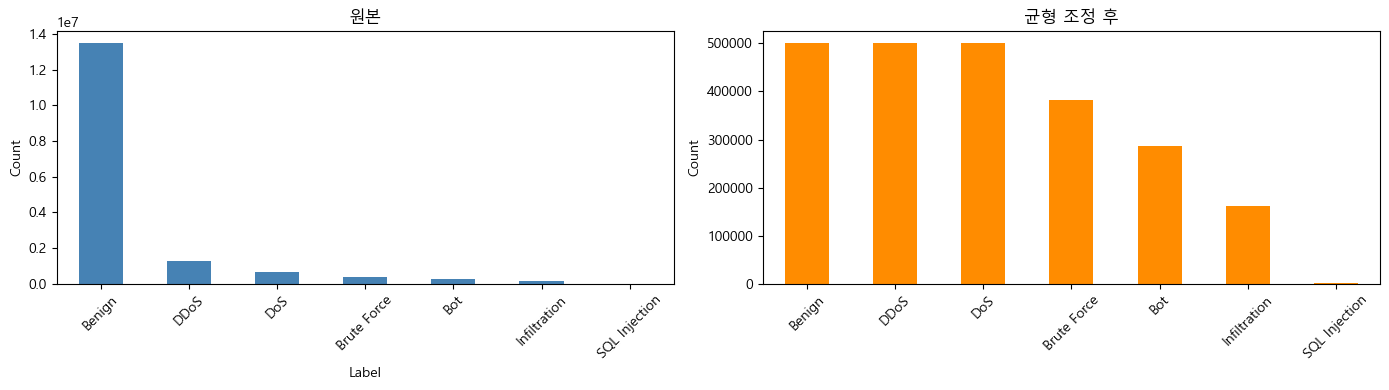

In [13]:
from imblearn.over_sampling import SMOTE

MAX_SAMPLES = 500000   # 다수 클래스 최대 샘플 수
MIN_SAMPLES = 1000     # 소수 클래스 최소 샘플 수 (SMOTE 목표)

idx2label = {v: k for k, v in label_mapping.items()}

# 스케일된 X를 DataFrame으로 합치기
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
df_scaled["Label"]     = raw["Label"].values
df_scaled["Label_enc"] = raw["Label_enc"].values

lc = df_scaled["Label"].value_counts()

# 다수 클래스 언더샘플링
parts = []
for label in lc.index:
    subset = df_scaled[df_scaled["Label"] == label]
    if len(subset) > MAX_SAMPLES:
        subset = resample(subset, replace=False, n_samples=MAX_SAMPLES, random_state=42)
    parts.append(subset)

df_under = pd.concat(parts, ignore_index=True)

print("=== 언더샘플링 후 분포 ===")
print(df_under["Label"].value_counts().to_string())

# 소수 클래스 SMOTE 오버샘플링
X_under = df_under[feature_cols].values
y_under = df_under["Label_enc"].values

under_counts = dict(zip(*np.unique(y_under, return_counts=True)))
smote_targets = {k: MIN_SAMPLES for k, v in under_counts.items() if v < MIN_SAMPLES}

if smote_targets:
    print(f"\nSMOTE 적용 클래스: { {idx2label[k]: v for k, v in smote_targets.items()} }")
    sm = SMOTE(sampling_strategy=smote_targets, random_state=42, k_neighbors=5)
    X_balanced, y_balanced = sm.fit_resample(X_under, y_under)
else:
    X_balanced, y_balanced = X_under, y_under

# 셔플
shuffle_idx = np.random.RandomState(42).permutation(len(y_balanced))
X_balanced  = X_balanced[shuffle_idx]
y_balanced  = y_balanced[shuffle_idx]

print("\n=== 최종 클래스 분포 ===")
unique, counts = np.unique(y_balanced, return_counts=True)
total = len(y_balanced)
for u, c in zip(unique, counts):
    print(f"  {idx2label[u]:<15} : {c:>8,}  ({c/total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lc.plot(kind="bar", ax=axes[0], color="steelblue", title="원본")
pd.Series(y_balanced).map(idx2label).value_counts().plot(
    kind="bar", ax=axes[1], color="darkorange", title="균형 조정 후")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 8. 전처리 결과 저장

In [14]:
X_final = X_balanced.astype(np.float32)
y_final = y_balanced.astype(np.int32)

# numpy 배열 저장
np.save(os.path.join(OUTPUT_DIR, "X.npy"), X_final)
np.save(os.path.join(OUTPUT_DIR, "y.npy"), y_final)

# 스케일러 저장
with open(os.path.join(OUTPUT_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

# 레이블 매핑 저장
with open(os.path.join(OUTPUT_DIR, "label_mapping.json"), "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)

# 피처 이름 저장
with open(os.path.join(OUTPUT_DIR, "feature_names.json"), "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

print("저장 완료!")
print(f"  X.npy              : {X_final.shape}")
print(f"  y.npy              : {y_final.shape}")
print(f"  scaler.pkl")
print(f"  label_mapping.json : {label_mapping}")
print(f"  feature_names.json : {len(feature_cols)}개 피처")

저장 완료!
  X.npy              : (2330915, 70)
  y.npy              : (2330915,)
  scaler.pkl
  label_mapping.json : {'Benign': 0, 'Bot': 1, 'Brute Force': 2, 'DDoS': 3, 'DoS': 4, 'Infiltration': 5, 'SQL Injection': 6}
  feature_names.json : 70개 피처


In [15]:
# 저장된 결과 검증
X_check = np.load(os.path.join(OUTPUT_DIR, "X.npy"))
y_check = np.load(os.path.join(OUTPUT_DIR, "y.npy"))

print("=== 저장된 데이터 검증 ===")
print(f"X shape : {X_check.shape}  dtype={X_check.dtype}")
print(f"y shape : {y_check.shape}  dtype={y_check.dtype}")

print("\n=== 최종 클래스 분포 ===")
unique, counts = np.unique(y_check, return_counts=True)
total = len(y_check)
for u, c in zip(unique, counts):
    print(f"  {idx2label[u]:<15} : {c:>8,}  ({c/total*100:.1f}%)")

print(f"\n총 샘플 : {total:,}")
print(f"NaN     : {np.isnan(X_check).sum()}")
print(f"Inf     : {np.isinf(X_check).sum()}")

=== 저장된 데이터 검증 ===
X shape : (2330915, 70)  dtype=float32
y shape : (2330915,)  dtype=int32

=== 최종 클래스 분포 ===
  Benign          :  500,000  (21.5%)
  Bot             :  286,191  (12.3%)
  Brute Force     :  381,790  (16.4%)
  DDoS            :  500,000  (21.5%)
  DoS             :  500,000  (21.5%)
  Infiltration    :  161,934  (6.9%)
  SQL Injection   :    1,000  (0.0%)

총 샘플 : 2,330,915
NaN     : 0
Inf     : 0
